# Simulating a quantum computer on your laptop

Welcome to the tensor network challenge of the MQST Qiskit Fall Fest 2026!

In 2011, Lanyon and collaborators ran the first universal digital quantum simulations on a
quantum computer built from six trapped ions, using sequences of up to a hundred gates
(Science 334, 57). Your laptop is a far bigger machine than six
ions in a vacuum chamber, so a reasonable question is whether it can do the same job, and if
it cannot, what exactly fails first.

That is the question you will answer:

*Can your laptop simulate a quantum computer, and what stops it?*

A state of $N$ spins needs $2^N$ complex amplitudes (= numbers). At $N = 300$, that is around $10^{82}$
gigabytes of information. The observable universe holds an estimated $10^{80}$ atoms, so even just writing the
state down is an impossible task, not to mention if we want to manipulate it to find a ground state. This is the so-called **many-body problem**.

The interesting part is that quantum dynamics does not
always use all that space. Quantum algorithms are designed to use it, but a spin chain
evolving for a short time may not, and if it does not, a laptop could follow the (at least short-time) dynamics of qubits. Finding the point at which our classical computers break and why is the whole challenge.

This challenge is divided into six parts:

- **Parts 1 and 2**: Build two exact simulators, one storing the full state vector and one using
  sparse matrices, and measure the limits of our machine.
- **Part 3**: Use these simulators to replicate the physics of the 2011 trapped-ion paper and reproduce its figures.
- **Part 4**: Build a Matrix Product State (MPS) simulator, a tensor network structure that compresses quantum entanglement rather than storing raw amplitudes.
- **Part 5**: Push every method until it breaks and determine what the limiting resource in our laptops really is in each regime.
- **Part 6**: Bonus research-level problems for the fastest hackers.

Parts 1 to 5 are the core challenge. Part 6 contains optional bonus extensions.

What you should hand in at the end of the hackathon is this notebook filled with your code and answers to the questions at the end of each section. All your results and analysis should be presented in the final team defense. The evaluation will be based on both this notebook and the presentation.

#### First install the necessary packages, if you have not already (`README.md`)


# Introduction

The paper we are going to reproduce simulates networks of interacting spin-1/2 particles. To
predict the dynamics of a system with Hamiltonian $H = \sum_k H_k$ we need
$|\psi(t)\rangle = e^{-iHt}|\psi(0)\rangle$. The individual terms $H_k$ do not commute, but the
Trotter formula

$$e^{-iHt} = \lim_{r\to\infty}\Big(\prod_k e^{-iH_k t/r}\Big)^r$$

lets a quantum computer approximate the evolution as a sequence of small gates, applied in $r$
digital steps. Finite $r$ leaves a Trotter error that shrinks as $r$ grows. Each Trotter step of duration $\delta t = t/r$ decomposes into layers of single-qubit rotations and two-qubit entangling gates:

<p align="center"><img src="imgs/trotter_step.svg" alt="Trotterization step in time evolution" width="480"/></p>

The other thing to fix before starting is how a state is stored. An $n$-qubit state has $2^n$
amplitudes $\psi_{b_1 b_2 \dots b_n}$, which we can hold as an array with one index per qubit
rather than as one long vector. On the left is the state as a single vector with one index of
dimension $2^n$; on the right is the state as a rank-$n$ tensor with one leg per qubit, each of
dimension 2:

<p align="center"><img src="imgs/state_representations.svg" alt="State representations" width="440"/></p>

A one-qubit gate is then a $2\times2$ matrix contracted with one index, and a two-qubit gate a
$2\times2\times2\times2$ tensor contracted with two. Applying a two-qubit gate to qubits 2 and 4
contracts those two legs while leaving the others open:

$$\psi'_{b_1 b_2' b_3 b_4'} = \sum_{b_2, b_4} U_{b_2' b_4', b_2 b_4} \, \psi_{b_1 b_2 b_3 b_4}$$

<p align="center"><img src="imgs/gate_contraction.svg" alt="Applying a two-qubit gate" width="380"/></p>

This computational scaling illustrates a fundamental principle of tensor simulation: never construct the dense $2^n \times 2^n$ matrix of a gate. Contracting a $k$-qubit gate directly into an $n$-qubit state tensor requires $O(2^n \cdot 2^k)$ operations, approximately $4\times10^6$ multiplications for a two-qubit gate on 20 qubits, compared to $O(2^n \cdot 2^n) \approx 10^{12}$ operations for a full matrix-vector multiplication.

Pay close attention to two critical conventions:
1. **Bit ordering (Endianness)**: In our tensor simulator, qubit $i$ corresponds to tensor axis $i$ (axis 0 is the most significant bit, or big-endian). Conversely, Qiskit orders its flat state vectors in little-endian order, where qubit 0 is the least significant bit.
2. **Tensor index ordering**: Reshaping a $4\times4$ two-qubit gate into shape $(2, 2, 2, 2)$ yields index order $(\text{out}_1, \text{out}_2, \text{in}_1, \text{in}_2)$. Any contraction must respect this input/output structure.

Most numerical discrepancies in tensor simulations stem from subtle endianness or index mismatches. We therefore define explicit conversion helpers (`to_flat` and `flat_be`) and use them deliberately. The check against Qiskit in Part 1 is specifically designed to verify these conventions.

Throughout we set $\hbar = 1$ and use dimensionless Hamiltonians, so time is measured by the
phase $\theta = Et$. Spin up is $|{\uparrow}\rangle = |0\rangle$ and spin down is
$|{\downarrow}\rangle = |1\rangle$.


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

In [3]:
# Useful constants and helpers for later:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H_GATE = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)


def to_flat(psi):
    """Flatten to Qiskit's little-endian vector (qubit 0 = least significant bit)."""
    n = psi.ndim
    return psi.transpose(*range(n - 1, -1, -1)).reshape(-1)


def flat_be(psi):
    """Flatten in our big-endian order (qubit 0 = most significant)."""
    return psi.reshape(-1)


# 1. Simulating the full state vector

The most direct way to simulate a quantum computer is to store every amplitude and update them
all whenever a gate is applied. We keep the state as a NumPy array of shape `(2,)*n` and apply
gates with `tensordot`.

## 1.1 Write your quantum gate library

Every unitary operation on single qubits and pairs of qubits can be built from rotation
operators. In quantum computing, a rotation about axis $\alpha \in \{X, Y, Z\}$ by an angle $\theta$ is generated by
the Pauli operator $\sigma_\alpha$:

$$R_\alpha(\theta) = e^{-i \frac{\theta}{2} \sigma_\alpha} = \cos(\theta/2)\, I - i\sin(\theta/2)\,\sigma_\alpha.$$

For two qubits, the collective Ising rotation along axis $X$ is
$R_{XX}(\theta) = e^{-i \frac{\theta}{2} X\otimes X}$, and the SWAP gate exchanges the states of two
qubits: $|01\rangle \leftrightarrow |10\rangle$.

Write your own functions implementing the following quantum gates: `RX(t)`, `RY(t)`, `RZ(t)`, `RXX(t)`, `RYY(t)`, `RZZ(t)`, `SWAP` and `CX` (controlled-NOT). Check them by comparing with Qiskit's own operators.

> Hint: for `RXX`, you can use `np.kron(X, X)` with Euler's formula; for `SWAP` and `CX`, build the $4\times 4$ permutation matrices.


In [4]:
# Defining tensor products of pauli matrices
XtimesX=np.kron(X, X)
YtimesY=np.kron(Y, Y)
ZtimesZ=np.kron(Z, Z)

# Defining rotation matrices
def Rx(theta):
    """Return the 1-qubit Rx rotation matrix."""
    return expm(-1j *( theta / 2) * X)


def Ry(theta):
    """Return the 1-qubit Ry rotation matrix."""
    return expm(-1j *( theta / 2) * Y)


def Rz(theta):
    """Return the 1-qubit Rz rotation matrix."""
    return expm(-1j *( theta / 2) * Z)


def Rxx(theta):
    """Return the 2-qubit Rxx rotation matrix."""
    return expm(-1j *( theta / 2) * XtimesX)


def Ryy(theta):
    """Return the 2-qubit Ryy rotation matrix."""
    return expm(-1j *( theta / 2) * YtimesY)


def Rzz(theta):
    """Return the 2-qubit Rzz rotation matrix."""
    return expm(-1j *( theta / 2) * ZtimesZ)


def swap():
    """Return the 2-qubit SWAP gate matrix."""
    return np.array([[1, 0, 0, 0],
                     [0, 0, 1, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1]], dtype=complex)


def cnot():
    """Return the 2-qubit CNOT gate matrix."""
    return np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]], dtype=complex)


# Check against Qiskit. Qiskit's matrices are little-endian, ours are big-endian,
# so for two-qubit gates we conjugate ours with SWAP to change the ordering.
t = 0.37
for name, mine, build in [
    ("RX", Rx(t), lambda qc: qc.rx(t, 0)),
    ("RY", Ry(t), lambda qc: qc.ry(t, 0)),
    ("RZ", Rz(t), lambda qc: qc.rz(t, 0)),
]:
    qc = QuantumCircuit(1)
    build(qc)
    print(name, np.allclose(mine, Operator(qc).data))

for name, mine, build in [
    ("RXX", Rxx(t), lambda qc: qc.rxx(t, 0, 1)),
    ("RYY", Ryy(t), lambda qc: qc.ryy(t, 0, 1)),
    ("RZZ", Rzz(t), lambda qc: qc.rzz(t, 0, 1)),
    ("SWAP", swap(), lambda qc: qc.swap(0, 1)),
    ("CX", cnot(), lambda qc: qc.cx(0, 1)),
]:
    qc = QuantumCircuit(2)
    build(qc)
    print(name, np.allclose(swap() @ mine @ swap(), Operator(qc).data))

RX True
RY True
RZ True
RXX True
RYY True
RZZ True
SWAP True
CX True


## 1.2 Initialize the state and apply gates

1. Write a function `init_state(n)` that creates the state $|00\dots 0\rangle$ as a NumPy array of shape `(2,)*n`.

2. Write a function `apply_1q` that contracts a $2\times2$ matrix into one axis, and another one `apply_2q` that contracts a $(2,2,2,2)$ tensor into two. In both cases `tensordot` puts the new axes at the front, so you have to move them back to where they belong.

> Hint: `np.tensordot(U, psi, axes=([1], [i]))` contracts the column index of `U` with axis `i` of `psi`, and leaves the result on axis 0. `np.moveaxis` puts it back.

In [5]:
def init_state(n):
    """|00...0> = |up up ... up> as a (2,)*n tensor."""
    psi = np.zeros((2,) * n, dtype=complex)
    psi[(0,) * n] = 1.0
    return psi
    

def apply_1q(psi, U, i):
    """Apply 2x2 unitary U to qubit i of the (2,)*n state tensor."""
    psi = np.tensordot(U, psi, axes=([1], [i]))
    # Move the new axis to the correct position:
    psi = np.moveaxis(psi, 0, i)
    return psi


def apply_2q(psi, U, i, j):
    """Apply 4x4 unitary U to qubits (i, j); row index ordered as |q_i q_j>."""
    # Reshape U to a (2, 2, 2, 2) tensor: (not contracted, not contracted, contracted_i, contracted_j)
    U = np.reshape(U, (2, 2, 2, 2))
    # Contract the input indices with the state tensor:
    psi = np.tensordot(U, psi, axes=([2, 3], [i, j]))
    # Move the new axes to the correct positions:
    psi = np.moveaxis(psi, [0, 1], [i, j])
    return psi

## 1.3 Build a circuit in Qiskit and verify your simulator

To verify our state vector simulator, construct a 3-qubit circuit in Qiskit and
simulate the exact same sequence with your tensor functions. Then compare both state vectors.

Remember the different conventions: qubit 0 is the least significant bit in Qiskit's flat state
vector, while in our tensor axis 0 is qubit 0. The helper `to_flat(psi)` converts our tensor
into Qiskit's flat convention.

1. Write a circuit with Qiskit in which you apply an `rz` gate to qubit 0 and
an `rxx` gate to qubits 1 and 2.
2. Apply the same circuit (series of operations) using our custom gate library (`apply_1q` and `apply_2q`).
3. Check the final state from both approaches agree.

> Hint: use `Statevector.from_instruction(qc).data` to get Qiskit's state vector, and
> `to_flat(psi)` for your simulator's state.

In [6]:
# ---------- Classical circuit using tensor networks ----------
psi = init_state(3)
angle_z = 0.37
angle_xx = 0.37

# Construct an equal prob entangled state by applying Hadamard gates to all qubits:
for i in range(3):
    psi = apply_1q(psi, H_GATE, i)

# Circuit simulation
psi = apply_1q(psi, Rz(angle_z), 0)
psi = apply_2q(psi, Rxx(angle_xx), 1, 2)
psi_classic = to_flat(psi) # Flatten the tensor network representation


# --------------- Quantum circuit using qiskit --------------
qc=QuantumCircuit(3)
qc.h([0, 1, 2])
qc.rz(angle_z, 0)
qc.rxx(angle_xx, 1, 2)
psi_quantum = Statevector.from_instruction(qc).data # Get the statevector from qiskit


# --------------------- Compare results ---------------------
print("Classical tensor network simulation:")
print(psi_classic)
print("Quantum circuit simulation using qiskit:")
print(psi_quantum)
print("")
print("States agree:", np.allclose(psi_quantum, psi_classic))
print("Overlap |<ψ_quantum|ψ_classic>| =", abs(np.vdot(psi_quantum, psi_classic)), "(Should be 1.0)")

Classical tensor network simulation:
[0.32962749-0.12785036j 0.35355339+0.j         0.32962749-0.12785036j
 0.35355339+0.j         0.32962749-0.12785036j 0.35355339+0.j
 0.32962749-0.12785036j 0.35355339+0.j        ]
Quantum circuit simulation using qiskit:
[0.32962749-0.12785036j 0.35355339+0.j         0.32962749-0.12785036j
 0.35355339+0.j         0.32962749-0.12785036j 0.35355339+0.j
 0.32962749-0.12785036j 0.35355339+0.j        ]

States agree: True
Overlap |<ψ_quantum|ψ_classic>| = 0.9999999999999996 (Should be 1.0)


## 1.4 How far can your laptop go?

Look at your laptop's RAM and predict the largest $n$ you can hold on paper. Then, try to apply a 2-qubit gate in the middle of the qubit chain to see whether your computer can handle it or not (only if you're brave enough or curious about what happens).

> Hint: save your progress in the notebook just in case.

In [7]:
import psutil


# Compute the number of bytes needed to store a statevector of n qubits in memory
def state_memory_GB(n):
    """Compute the number of bytes needed to store a statevector of n qubits."""
    return 2**n * 16 / (2**30)  # 16 bytes per complex number (8 bytes for real float and 8 for imaginary float), converted to GB

ram_available = psutil.virtual_memory().available / (2**30)  # Available RAM in GB


print("----- Memory requirements for storing statevectors of n qubits -----")
print(" n \t state size")
for n in [10, 20, 24, 26, 28, 30, 32, 40, 50]:
    print(f"{n:2d} \t {state_memory_GB(n):12.4f} GB")

# Theoretical maximum number of qubits that can be stored in available RAM 
max_n = int(np.floor(np.log2(ram_available * 2**30 / 16)))
# Each unitary gate in a quantum circuit needs to store x2 the statevector so 
# the maximum number of qubits gets lowered by 1.
max_n -= 1
# In practice, the computer will swap memory to disk/optimize memory usage by 
# compression so the actual maximum number of qubits might get bigger, but running 
# slower (since they won't be stored in RAM or will need to be decoded)


def simulation(n):
    t0 = time.time()
    psi = init_state(n)
    for i in range(n):
        psi = apply_1q(psi, H_GATE, i)
    psi = apply_2q(psi, Rxx(0.3), n // 2 - 1, n // 2)
    t1 = time.time()
    print(f"{n:2d} \t\t\t {t1-t0:12.4f} \t\t {state_memory_GB(n):12.4f} GB")
    del psi  # Free memory after each simulation


# Trying simulation within the safe limits
print("")
print("----- Simulating quantum circuits with tensor networks (safe limits) -----")
print("qubits simulated \t time taken (s) \t statevector size (GB)")
for n in range(2, max_n - 2): # Just a few to be completed in a reasonable time
    simulation(n)

"""
# Trying simulation beyond the safe limits (may take a long time or crash)
print("")
print("----- Simulating quantum circuits with tensor networks (beyond safe limits) -----")
print("qubits simulated \t time taken (s) \t statevector size (GB)")
simulation(max_n + 1) """

----- Memory requirements for storing statevectors of n qubits -----
 n 	 state size
10 	       0.0000 GB
20 	       0.0156 GB
24 	       0.2500 GB
26 	       1.0000 GB
28 	       4.0000 GB
30 	      16.0000 GB
32 	      64.0000 GB
40 	   16384.0000 GB
50 	 16777216.0000 GB

----- Simulating quantum circuits with tensor networks (safe limits) -----
qubits simulated 	 time taken (s) 	 statevector size (GB)
 2 			       0.0010 		       0.0000 GB
 3 			       0.0005 		       0.0000 GB
 4 			       0.0006 		       0.0000 GB
 5 			       0.0006 		       0.0000 GB
 6 			       0.0009 		       0.0000 GB
 7 			       0.0008 		       0.0000 GB
 8 			       0.0012 		       0.0000 GB
 9 			       0.0010 		       0.0000 GB
10 			       0.0011 		       0.0000 GB
11 			       0.0015 		       0.0000 GB
12 			       0.0186 		       0.0001 GB
13 			       0.0191 		       0.0001 GB
14 			       0.0066 		       0.0002 GB
15 			       0.0133 		       0.0005 GB
16 			       0.0328 		       0.0010 GB
17 			

'\n# Trying simulation beyond the safe limits (may take a long time or crash)\nprint("")\nprint("----- Simulating quantum circuits with tensor networks (beyond safe limits) -----")\nprint("qubits simulated \t time taken (s) \t statevector size (GB)")\nsimulation(max_n + 1) '

### Questions for Part 1

1. Calculate the memory needed to store a state vector as a function of $n$. What is the largest $n$ your laptop could theoretically hold in RAM?
2. What happened when you applied a 2-qubit gate on a large state vector? Which resource ran out first?

> Your answer:

# 2. The same physics with less memory

Part 1 shows that there is a maximum chain size $n$ that our laptop can afford with our state vector simulation. But can we do it better?

Let us consider the Hamiltonian of a spin model as a matrix. It has $2^N \times 2^N$ entries, but if we write it out we will notice that almost none of them are non-zero: each $\sigma_z^i$ term is diagonal, and each $\sigma_x^i\sigma_x^j$ term connects one basis state to exactly one other. A model with $O(N^2)$ terms therefore has $O(N^2 2^N)$ non-zeros out of $4^N$ entries, which at $N = 16$ is a matrix that is 0.18% filled!

We can take advantage of this by keeping $H$ in a sparse format, which stores only the non-zeros and their positions (instead of exponentially many zeros). On the other hand, to evolve the state under $e^{-iHt}$ instead of taking the matrix exponential of the sparse matrix (which would be dense), we compute the action $e^{-iHt}|\psi\rangle$ directly with a Krylov subspace method, which only ever needs matrix-vector products. `scipy.sparse.linalg.expm_multiply` does this.

Note this saves a lot of memory while keeping the state exact, with no approximations: no Trotter error, no tensor truncation. It is also what most many-body physics papers actually use for small to medium systems.

### The model we will study

From here on we use the long-range transverse Ising model,

$$H(\alpha) = \sum_{i<j} \frac{J}{|i-j|^{\alpha}}\,\sigma_x^i \sigma_x^j + B\sum_i \sigma_z^i,$$

because the exponent $\alpha$ controls how *hard* the physics is: 
- At $\alpha = \infty$ only neighbours are coupled. 
- Around $\alpha = 3$ the couplings decay quickly, as they do in dipolar systems and Rydberg arrays. 
- Around $\alpha = 1.4$ we are in the regime of a real trapped-ion chain. 
- At $\alpha = 0$ every pair is coupled with equal strength.

## Tasks

1. Write a helper function `ising_couplings(n, alpha, J=1.0)` that returns the list of pairs and coupling strengths `[(i, j, J_ij)]` with $J_{ij} = J / |i - j|^\alpha$.
2. Write a function `H_longrange_sparse(n, alpha, J=1.0, B=0.5)` that builds $H(\alpha)$ using `scipy.sparse` matrices (iterating over `ising_couplings`).
3. Write a function `evolve_krylov(H, psi_flat, t)` that applies $e^{-iHt}$ directly to a state vector using `scipy.sparse.linalg.expm_multiply`.
4. Check that your sparse Hamiltonian and Krylov evolution give the exact same results as the dense calculation (e.g. comparing with `scipy.linalg.expm` at small $n \approx 6$).
5. Investigate what we have won using sparse matrices instead of dense ones: compare computation times and memory usage, test where this approach breaks on your computer, and draw your own conclusions from your own reasoning and code.

> Hints:
> - To build a sparse Pauli operator acting on qubit $i$ of an $n$-qubit chain, you can use Kronecker products of sparse identity matrices:
>   `sp.kron(sp.identity(2**i, format="csr"), sp.kron(sp.csr_matrix(P), sp.identity(2**(n - i - 1), format="csr")))`
> - `expm_multiply(A, v)` returns $\exp(A) v$.
> - You can check whether $H_{\text{sparse}}$ matches dense $H$ on small $n$ using `.toarray()`.


In [8]:
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

# ---------- Sparse Hamiltonian construction ----------

def ising_couplings(n, alpha, J=1.0):
    """[(i, j, J_ij)] with J_ij = J/|i-j|^alpha.
    
    alpha=0   -> all-to-all coupling (Lanyon model)
    alpha=inf -> nearest neighbours only
    """

    couplings = []
    for i in range(n):
        for j in range(i + 1, n):
            dist = abs(j - i) # Compute distance between qubits i and j
            if np.isinf(alpha): # Wierd case: nearest neighbour only
                if dist == 1:
                    couplings.append((i, j, float(J)))
            else:
                J_ij = J / (dist**alpha) # if alpha is infinite, this will be 0 for all but nearest neighbours
                couplings.append((i, j, float(J_ij)))
    return couplings


def _sparse_single_op(P, i, n):
    """Helper: embed single-qubit sparse Pauli P into an n-qubit chain."""
    # Creates a sparse matrix of size 2^n x 2^n with P acting on qubit i and identity on all other qubits.
    left = sp.identity(2**i, format="csr", dtype=complex)
    right = sp.identity(2 ** (n - i - 1), format="csr", dtype=complex)
    return sp.kron(left, sp.kron(sp.csr_matrix(P, dtype=complex), right, format="csr"), format="csr")


def H_longrange_sparse(n, alpha, J=1.0, B=0.5):
    """Sparse long-range transverse-field Ising Hamiltonian using scipy.sparse.
    
    H = sum_{i<j} J_ij (sigma_x^i sigma_x^j) + B sum_i sigma_z^i
    """
    dim = 2**n
    Hamiltonian = sp.csr_matrix((dim, dim), dtype=complex)

    # 1. Transverse field term: B * sum_i sigma_z^i
    if B != 0.0:
        for i in range(n):
            Hamiltonian += B * _sparse_single_op(Z, i, n)

    # 2. Interaction term: sum_{i<j} J_ij * (sigma_x^i sigma_x^j)
    couplings = ising_couplings(n, alpha, J=J)
    for i, j, J_ij in couplings:
        # sigma_x^i * sigma_x^j
        Xi = _sparse_single_op(X, i, n)
        Xj = _sparse_single_op(X, j, n)
        Hamiltonian += J_ij * (Xi @ Xj)

    return Hamiltonian

def evolve_krylov(H, psi_flat, t):
    """Exact |psi(t)> = exp(-i H t)|psi(0)> using scipy.sparse.linalg.expm_multiply."""
    return expm_multiply(-1j*H*t, psi_flat)


# ---------- Model testing ----------
n_test = 5
alpha_test = 1.0
t_test = 0.8

# Sparse evolution
H_sparse = H_longrange_sparse(n_test, alpha_test, J=1.0, B=0.5)
psi = to_flat(init_state(n_test)) # Flatten the initial state to a vector because expm_multiply expects a 1D array

psi_krylov = evolve_krylov(H_sparse, psi, t_test)

# Dense evolution
H_dense = H_sparse.toarray() # Convert sparse matrix to dense for comparison
psi_dense = expm(-1j * H_dense * t_test) @ psi

print("Matches dense:", np.allclose(psi_krylov, psi_dense))
print("Overlap ||   :", abs(np.vdot(psi_krylov, psi_dense)))

# ---------- Benchmarking ----------
print("")
print("----- Benchmarking sparse vs dense evolution -----")
print("n \t t_build (s) \t t_sparse (s) \t t_dense (s) \t NNZ     \t memory (MB)")
for n in [8, 10, 12, 11, 14, 16]:
    t0 = time.perf_counter()
    H_s = H_longrange_sparse(n, alpha = alpha_test, J=1.0, B=0.5)
    t_build = time.perf_counter() - t0
    
    psi = to_flat(init_state(n))
    
    t0 = time.perf_counter()
    psi_t = evolve_krylov(H_s, psi, t=1.0)
    t_sparse = time.perf_counter() - t0

    if n <= 11:  # Only do dense evolution for small n to avoid memory issues
        t0 = time.perf_counter()
        H_dense = H_s.toarray() 
        psi_dense = expm(-1j * H_dense * t_test) @ psi
        t_dense = time.perf_counter() - t0
    else:
        t_dense = "skiped"  # Skip dense evolution for larger n
    
    nnz = H_s.nnz
    mem_mb = (H_s.data.nbytes + H_s.indices.nbytes + H_s.indptr.nbytes + psi_t.nbytes) / (1024**2)
    try:
        print(f"n={n:2d} \t {t_build:.3f} s \t {t_sparse:.3f} s \t {t_dense:.3f} s \t {nnz:9d} \t {mem_mb:7.2f} MB")
    except:
        print(f"n={n:2d} \t {t_build:.3f} s \t {t_sparse:.3f} s \t {t_dense}   \t {nnz:9d} \t {mem_mb:7.2f} MB")

Matches dense: True
Overlap ||   : 1.0000000000000004

----- Benchmarking sparse vs dense evolution -----
n 	 t_build (s) 	 t_sparse (s) 	 t_dense (s) 	 NNZ     	 memory (MB)
n= 8 	 0.100 s 	 0.005 s 	 0.124 s 	      7354 	    0.15 MB
n=10 	 0.147 s 	 0.019 s 	 1.041 s 	     46852 	    0.91 MB
n=12 	 0.396 s 	 0.114 s 	 skiped   	    273508 	    5.29 MB
n=11 	 0.220 s 	 0.043 s 	 8.442 s 	    114688 	    2.23 MB
n=14 	 1.252 s 	 0.854 s 	 skiped   	   1503896 	   29.00 MB
n=16 	 5.743 s 	 6.076 s 	 skiped   	   7916986 	  152.25 MB


### Questions for Part 2

1. Did using sparse matrices change the scaling problem with system size $n$ (memory and computation time)?
2. At what system size $n$ does your sparse Krylov solver run out of memory or time, and why does $|\psi(t)\rangle$ fail to remain sparse during time evolution?

> Your answer:


# 3. Reproducing the 2011 trapped-ion experiment

In 2011, B. P. Lanyon and collaborators ran the first universal digital quantum simulations of spin models on a quantum computer built from trapped $^{40}\text{Ca}^+$ ions [1].

They investigated spin systems governed by the Hamiltonian:

$$H = B\sum_i \sigma_z^i + \sum_{i<j}\Big( J_{xx}\,\sigma_x^i\sigma_x^j + J_{yy}\,\sigma_y^i\sigma_y^j + J_{zz}\,\sigma_z^i\sigma_z^j \Big)$$

where the simulated evolution is parameterized by the dimensionless phase $\theta = E t$.

Their trapped-ion processor natively executed two operations:
- A collective magnetic field: $O_2(\theta) = e^{-i\theta \sum_i \sigma_z^i}$ (implemented as single-qubit $R_Z$ rotations on all ions).
- An entangling Mølmer-Sørensen interaction: $O_4(\theta) = e^{-i\theta \sum_{i<j} \sigma_x^i \sigma_x^j}$ (acting as two-qubit $R_{XX}$ entangling gates between ion pairs).

Because the field and interaction terms do not commute, continuous time evolution must be approximated by digital Trotterization. In the paper's headline result (Figure 1A), they simulated two spins initialized in $|{\uparrow\uparrow}\rangle = |00\rangle$ with $B = 0.5$ and $J_{xx} = 1.0$, evolving to $\theta_a = \pi / (2\sqrt{2})$. At this point, the spins become maximally entangled, and the ideal state fidelity dramatically improved from 61% (with 1 Trotter step) to 98% (with 4 Trotter steps).

Furthermore, the authors showed that by symmetrizing the Trotter step (second-order Trotter), the leading error cancels out, achieving higher precision with fewer physical gate layers!

## Tasks

1. **Write one Trotter step (`trotter_step_own`)**:

   Implement a first-order Trotter step $U(\delta\theta) \approx e^{-i H_{\text{field}} \delta\theta} e^{-i H_{\text{int}} \delta\theta}$ on our state tensor simulator, applying $R_Z$ rotations for the field and $R_{XX}, R_{YY}, R_{ZZ}$ rotations for the couplings.
2. **Build the identical circuit in Qiskit (`trotter_circuit`)**:

   Construct the equivalent sequence as a Qiskit `QuantumCircuit` using `qc.rz`, `qc.rxx`, etc., and verify that both simulators agree.
3. **Reproduce the digitized dynamics (Figure 1A)**:

   Simulate the 2-spin dynamics starting from $|00\rangle$ across digital resolutions $r \in [1, 2, 3, 4]$ and compare against the exact continuous evolution from matrix exponential `expm`. Observe how the digitized points converge onto the exact curves as $r$ increases.
4. **Implement the second-order symmetric step (`trotter_step_own_2nd`)**:

   Symmetrize the step: $\exp(-i\frac{\delta\theta}{2} H_{\text{field}}) \exp(-i\delta\theta H_{\text{int}}) \exp(-i\frac{\delta\theta}{2} H_{\text{field}})$.
5. **Investigate the cost of accuracy**:

   Compare the convergence rates of first-order vs second-order Trotter (how does error scale with step size $\delta\theta$ and number of gate layers?). Optionally, run the circuit on Qiskit Aer with finite shots (e.g. 500 shots) to see what experimental data looked like on real hardware.

> Hints:
> - *Angle conventions*: The Hamiltonian term $B \sigma_z$ generates evolution $\exp(-i B \delta\theta Z)$. Our gate definition is $R_Z(\theta) = \exp(-i \frac{\theta}{2} Z)$. Therefore, to simulate $B \sigma_z$, you must pass angle $\theta = 2 B \delta\theta$ to `RZ`! Similarly, pass $2 J_{xx} \delta\theta$ to `RXX`.
> - *Second-order step*: A half-step of the magnetic field uses angle $B \delta\theta$ (instead of $2 B \delta\theta$).
> - *Continuous benchmark*: To benchmark against exact continuous evolution, build $H = B(Z \otimes I + I \otimes Z) + J_{xx}(X \otimes X)$ using `np.kron`, and compute $|\psi(\theta)\rangle = \text{expm}(-i H \theta)|\psi_0\rangle$ (or reuse your Krylov solver from Part 2).


In [9]:
def trotter_step_own(psi, dtheta, B=0.0, Jxx=0.0, Jyy=0.0, Jzz=0.0, pairs=None):
    """First-order Trotter step: apply field layer, then coupling layer on state tensor psi."""
    n = psi.ndim
    if pairs is None:
        pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    # 1. Collective magnetic field layer: exp(-i * B * dtheta * Z) -> angle = 2 * B * dtheta
    if B != 0.0:
        rz_gate = Rz(2.0 * B * dtheta)
        for i in range(n):
            psi = apply_1q(psi, rz_gate, i)

    # 2. Entangling coupling layers: exp(-i * J * dtheta * P@P) -> angle = 2 * J * dtheta
    if Jxx != 0.0:
        rxx_gate = Rxx(2.0 * Jxx * dtheta)
        for i, j in pairs:
            psi = apply_2q(psi, rxx_gate, i, j)

    if Jyy != 0.0:
        ryy_gate = Ryy(2.0 * Jyy * dtheta)
        for i, j in pairs:
            psi = apply_2q(psi, ryy_gate, i, j)

    if Jzz != 0.0:
        rzz_gate = Rzz(2.0 * Jzz * dtheta)
        for i, j in pairs:
            psi = apply_2q(psi, rzz_gate, i, j)

    return psi


def trotter_circuit(n, steps, dtheta, B=0.0, Jxx=0.0, Jyy=0.0, Jzz=0.0, pairs=None):
    """Build the identical digital Trotter sequence as a Qiskit QuantumCircuit."""
    if pairs is None:
        pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    qc = QuantumCircuit(n)

    for _ in range(steps):
        # 1. Magnetic field layer
        if B != 0.0:
            for i in range(n):
                qc.rz(2.0 * B * dtheta, i)

        # 2. Coupling layers
        if Jxx != 0.0:
            for i, j in pairs:
                qc.rxx(2.0 * Jxx * dtheta, i, j)
        if Jyy != 0.0:
            for i, j in pairs:
                qc.ryy(2.0 * Jyy * dtheta, i, j)
        if Jzz != 0.0:
            for i, j in pairs:
                qc.rzz(2.0 * Jzz * dtheta, i, j)

    return qc


def trotter_step_own_2nd(psi, dtheta, B=0.0, Jxx=0.0, Jyy=0.0, Jzz=0.0, pairs=None):
    """Second-order symmetric Trotter step: half field -> full couplings -> half field."""
    n = psi.ndim
    if pairs is None:
        pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    # 1. Half magnetic field layer (angle = B * dtheta)
    if B != 0.0:
        rz_half = Rz(B * dtheta)
        for i in range(n):
            psi = apply_1q(psi, rz_half, i)

    # 2. Full coupling layers (angle = 2 * J * dtheta)
    if Jxx != 0.0:
        rxx_gate = Rxx(2.0 * Jxx * dtheta)
        for i, j in pairs:
            psi = apply_2q(psi, rxx_gate, i, j)

    if Jyy != 0.0:
        ryy_gate = Ryy(2.0 * Jyy * dtheta)
        for i, j in pairs:
            psi = apply_2q(psi, ryy_gate, i, j)

    if Jzz != 0.0:
        rzz_gate = Rzz(2.0 * Jzz * dtheta)
        for i, j in pairs:
            psi = apply_2q(psi, rzz_gate, i, j)

    # 3. Half magnetic field layer (angle = B * dtheta)
    if B != 0.0:
        rz_half = Rz(B * dtheta)
        for i in range(n):
            psi = apply_1q(psi, rz_half, i)
            
    return psi

Trotter Step Simulators Match: True
Overlap |<custom|qiskit>|: 1.0000000000000009


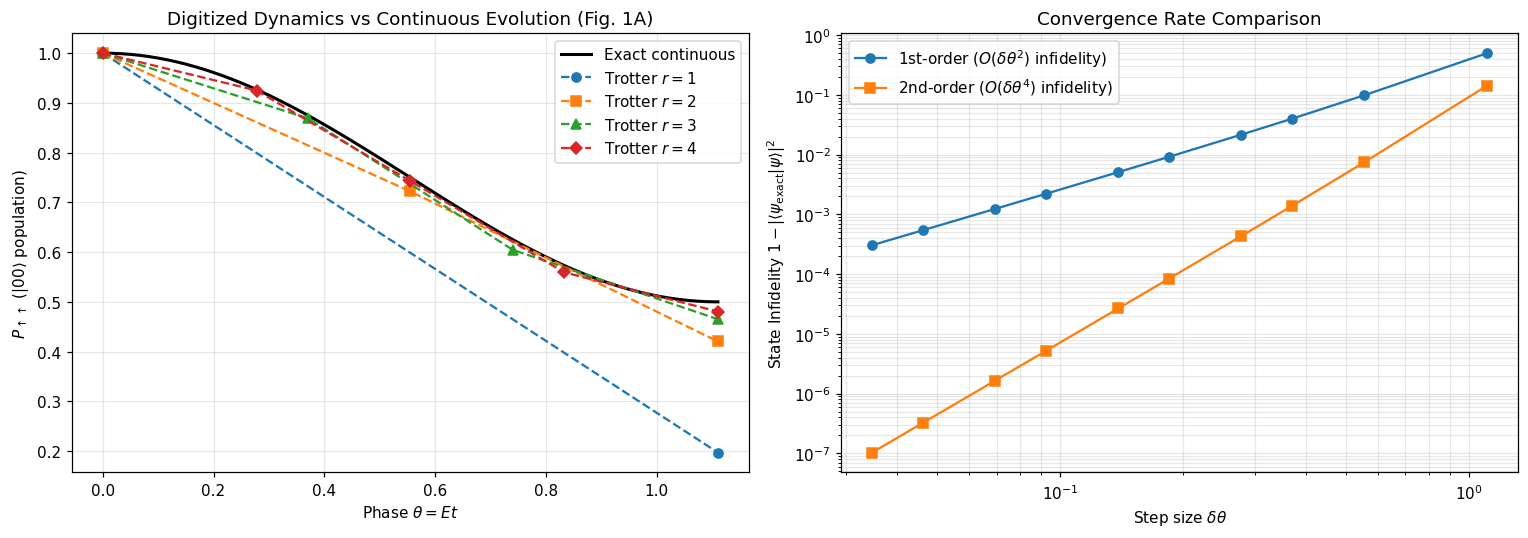

In [10]:
# ---------- Task 2: Verify agreement between custom simulator and Qiskit circuit ----------
n_qubits = 2
dtheta_test = 0.2
steps_test = 3
B_test, Jxx_test = 0.5, 1.0

psi_test = init_state(n_qubits)
for _ in range(steps_test):
    psi_test = trotter_step_own(psi_test, dtheta_test, B=B_test, Jxx=Jxx_test)
psi_custom_flat = to_flat(psi_test)

qc_test = trotter_circuit(n_qubits, steps_test, dtheta_test, B=B_test, Jxx=Jxx_test)
psi_qiskit = Statevector.from_instruction(qc_test).data

print("Trotter Step Simulators Match:", np.allclose(psi_custom_flat, psi_qiskit))
print("Overlap |<custom|qiskit>|:", abs(np.vdot(psi_custom_flat, psi_qiskit)))


# ---------- Task 3 & 5: Reproduce digitized dynamics (Lanyon et al. Figure 1A) ----------
B_val = 0.5
Jxx_val = 1.0
theta_max = np.pi / (2 * np.sqrt(2))  # Entangling point theta_a ≈ 1.11

# Continuous benchmark: H = B*(Z⊗I + I⊗Z) + Jxx*(X⊗X)
H_cont = B_val * (np.kron(Z, I2) + np.kron(I2, Z)) + Jxx_val * np.kron(X, X)
psi0_flat = np.array([1, 0, 0, 0], dtype=complex)  # |00> state

# Fine continuous curve
theta_grid = np.linspace(0, theta_max, 200)
p00_cont = []
for th in theta_grid:
    psi_th = expm(-1j * H_cont * th) @ psi0_flat
    p00_cont.append(abs(psi_th[0]) ** 2)

# Digitized Trotter runs for r in [1, 2, 3, 4]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Dynamics
axes[0].plot(theta_grid, p00_cont, "k-", label="Exact continuous", lw=2)

markers = ["o", "s", "^", "D"]
for r, m in zip([1, 2, 3, 4], markers):
    dtheta = theta_max / r
    theta_pts = [k * dtheta for k in range(r + 1)]
    
    psi_r = init_state(2)
    p00_pts = [abs(flat_be(psi_r)[0]) ** 2]
    
    for _ in range(r):
        psi_r = trotter_step_own(psi_r, dtheta, B=B_val, Jxx=Jxx_val)
        p00_pts.append(abs(flat_be(psi_r)[0]) ** 2)
        
    axes[0].plot(theta_pts, p00_pts, marker=m, linestyle="--", label=f"Trotter $r={r}$")

axes[0].set_xlabel(r"Phase $\theta = Et$")
axes[0].set_ylabel(r"$P_{\uparrow\uparrow}$ ($|00\rangle$ population)")
axes[0].set_title("Digitized Dynamics vs Continuous Evolution (Fig. 1A)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error scaling: 1st order vs 2nd order symmetric Trotter at theta_max
psi_exact = expm(-1j * H_cont * theta_max) @ psi0_flat
r_vals = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32])
err_1st, err_2nd = [], []

for r in r_vals:
    dth = theta_max / r
    
    # 1st-order run
    psi_1 = init_state(2)
    for _ in range(r):
        psi_1 = trotter_step_own(psi_1, dth, B=B_val, Jxx=Jxx_val)
    err_1st.append(1.0 - abs(np.vdot(psi_exact, flat_be(psi_1))) ** 2)
    
    # 2nd-order run
    psi_2 = init_state(2)
    for _ in range(r):
        psi_2 = trotter_step_own_2nd(psi_2, dth, B=B_val, Jxx=Jxx_val)
    err_2nd.append(1.0 - abs(np.vdot(psi_exact, flat_be(psi_2))) ** 2)

axes[1].loglog(theta_max / r_vals, err_1st, "o-", label=r"1st-order ($O(\delta\theta^2)$ infidelity)")
axes[1].loglog(theta_max / r_vals, err_2nd, "s-", label=r"2nd-order ($O(\delta\theta^4)$ infidelity)")
axes[1].set_xlabel(r"Step size $\delta\theta$")
axes[1].set_ylabel(r"State Infidelity $1 - |\langle\psi_{\mathrm{exact}}|\psi\rangle|^2$")
axes[1].set_title("Convergence Rate Comparison")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

### Questions for Part 3

In the 2011 paper, going from $r=1$ to $r=4$ digital steps increased the process fidelity from 61% to 98%, but required four times as many physical gates.

1. How does the simulation error scale with step size $\delta\theta$ for first-order vs second-order Trotter?
2. Why does the second-order symmetric step achieve higher accuracy with fewer physical gate layers?
3. On physical quantum hardware (like the ion trap), why can we not simply choose $r = 100,000$ to eliminate all Trotter error? What fundamental tension exists on quantum processors that does not exist on your laptop?

> Your answer:


# 4. Matrix Product States (MPS)

Parts 1 and 2 showed that simulating quantum dynamics with state vectors requires tracking $2^n$ probability amplitudes, hitting a memory wall at a given number of qubits $n$ on a laptop.

However, the foundational discovery of tensor networks is that the vast majority of states in the Hilbert space are unphysical. For systems governed by local interactions, physical ground states and low-energy dynamics satisfy the Area Law of Entanglement: the entanglement entropy between a subsystem and the rest of the chain scales with the area of the boundary, rather than the volume. In a 1D chain, the boundary between two halves is just a single point!

Because physical entanglement is bounded, we can factorize the rank-$n$ state tensor into a 1D chain of $n$ small three-index tensors. This tensor network structure is called a **Matrix Product State (MPS)**:

$$\psi_{b_1 b_2 \cdots b_n} = A^{[1]}_{b_1} A^{[2]}_{b_2} \cdots A^{[n]}_{b_n}$$

where each physical index $b_i \in \{0, 1\}$ selects a matrix of shape $\chi_{i-1} \times \chi_i$.

<p align="center"><img src="imgs/mps_representation.svg" alt="Matrix product state" width="480"/></p>

The **bond dimension** $\chi$ controls the maximum amount of entanglement the ansatz can carry across any cut. A product state has $\chi = 1$, while a maximally entangled arbitrary state would require $\chi = 2^{n/2}$. Storing an MPS requires only $O(n \cdot d \cdot \chi^2) = O(n \chi^2)$ memory, which is linear in $n$ rather than exponential!

### Time-Evolving Block Decimation (TEBD)

To simulate quantum circuits and time evolution on an MPS:
1. **Single-qubit gates**: Contract the $2 \times 2$ gate into the physical index of tensor $A^{[i]}$. This is exact, local, and does not alter the bond dimension.
2. **Two-qubit local gates**: Contract adjacent tensors $A^{[i]}, A^{[i+1]}$ and the $4 \times 4$ gate $U$ into a single 4-index tensor, reshape into a matrix of size $(2l) \times (2r)$, and compute its Singular Value Decomposition (SVD):
   $$M = U_{\text{svd}} \, S \, V^\dagger$$
   Truncating to at most $\chi_{\text{max}}$ singular values keeps only the dominant Schmidt modes. The discarded weight $\sum_{k > \chi_{\text{max}}} s_k^2$ is the truncation error we accept.
3. **Entanglement entropy**: The Schmidt singular values at any bond yield the von Neumann entanglement entropy $S = -\sum_k p_k \ln p_k$ directly, where $p_k = s_k^2 / \sum_j s_j^2$.
4. **Canonical gauge**: The SVD yields true Schmidt coefficients (ensuring optimal truncation) only if the MPS is in canonical form (e.g. right-canonicalizing the chain via right-to-left SVD sweeps).
5. **Long-range gates**: A 1D MPS natively couples only nearest neighbors. To interact distant sites $i < j$, we route site $i$ next to site $j$ using SWAP gates, apply $U$, and SWAP site $i$ back.

In order to implement TEBD, your team has the freedom to choose whichever path suits you best:

### Path A: Use a Tensor Network Package (`TeNPy`)
Learn how to use a standard condensed-matter tensor network library like [TeNPy (Tensor Network Python)](https://tenpy.readthedocs.io/).
TeNPy handles tensors, gauge transformations, and Schmidt decompositions under the hood:
```python
from tenpy.networks.site import SpinHalfSite
from tenpy.networks.mps import MPS

# 1. Initialize |00...0>
site = SpinHalfSite(conserve=None)
psi = MPS.from_product_state([site] * n, ["up"] * n)

# 2. Inspect bond dimension and entanglement entropy at every cut:
print("Bond dimensions:", psi.chi)
print("Entanglement entropy:", psi.entanglement_entropy())
```
Follow the [TeNPy TEBD Guide](https://tenpy.readthedocs.io/en/latest/intro/simulations.html) to evolve states under the transverse-field Ising model, track entanglement entropy growth, and observe bond dimension truncation.

### Path B: The Hacker Route (Build TEBD from scratch)
For those who want to understand the exact tensor contractions and SVD truncations under the hood:
Implement the core MPS representations and TEBD operations below. We provide the mathematical definitions, tensor shapes, and docstrings with hints so you can construct the algorithms yourself.

## Tasks

1. Implement functions `mps_product_state`, `right_canonicalize`, and inspection helpers (see cell below).
2. Apply single-qubit and two-qubit gates to an MPS.
3. Implement SVD truncatation to at most $\chi_{\text{max}}$, and track the discarded weight.
4. Calculate the von Neumann entanglement entropy $S = -\sum_k p_k \ln p_k$ from the Schmidt values across each bond.
5. Implement non-local gates using SWAP routing for long-range couplings.
6. With no truncation ($\chi_{\text{max}} = \text{None}$), verify that your MPS exactly reproduces the state vector from Part 1 across a small circuit.

> Hints for Path B:
> - *Single-qubit contraction*: Use `np.einsum("ab,lbr->lar", U, mps[i])`.
> - *Two-qubit contraction*: Contract $A_1$ and $A_2$ with `theta = np.einsum("lar,rbs->labs", A1, A2)`, then contract with $U$ reshaped to $(2, 2, 2, 2)$, reshape into matrix $(l \cdot 2, 2 \cdot r)$, and compute `safe_svd`.
> - *Norm preservation*: After truncation, rescale $S_{\text{kept}}$ by $\|\vec{S}\| / \|\vec{S}_{\text{kept}}\|$ so the total state norm is preserved.
> - *SWAP routing*: Truncate on the outward sweep and gate (`chi_max`), but keep the return sweep exact (`chi_max=None`) because it runs against the canonical gauge.

**Note for Path A (TeNPy): skip the cell below and proceed directly to the next one.**

In [11]:
## This cell is exclusive for path B participants.

# Helpers: numerical stability and SWAP matrix
def safe_svd(M):
    """SVD with fallback to slower robust driver if LAPACK fails."""
    try:
        return np.linalg.svd(M, full_matrices=False)
    except np.linalg.LinAlgError:
        from scipy.linalg import svd as _sp_svd
        return _sp_svd(M, full_matrices=False, lapack_driver="gesvd")

SWAP = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=complex)


def mps_product_state(n):
    """|00...0> as an MPS: n tensors of shape (1, 2, 1)."""
    mps = []
    for _ in range(n):
        tensor = np.zeros((1, 2, 1), dtype=complex)
        tensor[0, 0, 0] = 1.0  # |0> = spin up
        mps.append(tensor)
    return mps


def right_canonicalize(mps):
    """Sweep right->left so every tensor is right-canonical (orthogonality center at site 0)."""
    n = len(mps)
    for i in range(n - 1, 0, -1):
        l, d, r = mps[i].shape
        # 1. Reshape mps[i] of shape (l, d, r) into a matrix M of shape (l, d * r)
        M = mps[i].reshape(l, d * r)
        # 2. SVD: M = U @ diag(S) @ Vh
        U, S, Vh = safe_svd(M)
        # 3. Store Vh reshaped into (-1, d, r) back in mps[i]
        new_chi = Vh.shape[0]
        mps[i] = Vh.reshape(new_chi, d, r)
        # 4. Contract (U * S) into the right virtual bond of mps[i-1]
        mps[i - 1] = np.einsum("lar,rk->lak", mps[i - 1], U * S)


def mps_to_dense(mps):
    """Contract MPS back to a (2,)*n tensor (small n only!)."""
    n = len(mps)
    # Start with first tensor: shape (1, 2, r0) -> squeeze first dummy index -> (2, r0)
    T = mps[0][0, :, :]  # shape: (d_0, r_0)
    for i in range(1, n):
        # T has shape (d_0, d_1, ..., d_{i-1}, r_{i-1})
        # mps[i] has shape (r_{i-1}, d_i, r_i)
        T = np.tensordot(T, mps[i], axes=(-1, 0))
    # Squeeze the trailing dummy index of size 1
    return np.squeeze(T, axis=-1)


def max_bond(mps):
    """Return maximum virtual bond dimension across the chain."""
    return max(tensor.shape[2] for tensor in mps[:-1]) if len(mps) > 1 else 1


def expect_1site_mps(mps, op, i):
    """<psi|op_i|psi> / <psi|psi> by transfer-matrix contraction."""
    n = len(mps)
    # Environment transfer matrix from the left: shape (chi_left, chi_left*)
    L = np.ones((1, 1), dtype=complex)
    N = np.ones((1, 1), dtype=complex)
    
    for site in range(n):
        A = mps[site]  # shape: (l, d, r)
        if site == i:
            # Transfer matrix with operator
            A_op = np.einsum("ab,lbr->lar", op, A)
            L = np.einsum("lr,lar,Lsk->rk", L, A_op, A.conj())
        else:
            L = np.einsum("lr,ldr,lds->rs", L, A, A.conj())
        
        # Norm transfer matrix
        N = np.einsum("lr,ldr,lds->rs", N, A, A.conj())
        
    return (L[0, 0] / N[0, 0]).real


def von_neumann_entropy(singular_values):
    """Von Neumann entanglement entropy S = -sum p_k ln(p_k) from Schmidt singular values."""
    s = np.asarray(singular_values, dtype=float)
    s = s[s > 1e-15]
    norm_sq = np.sum(s**2)
    if norm_sq < 1e-15:
        return 0.0
    p = (s**2) / norm_sq
    return -np.sum(p * np.log(p))


def entropy_profile(mps):
    """Entanglement entropy at every bond (uses a canonicalized copy; original untouched)."""
    n = len(mps)
    mps_copy = [A.copy() for A in mps]
    right_canonicalize(mps_copy)
    
    entropies = []
    for i in range(n - 1):
        l, d, r = mps_copy[i].shape
        # Reshape to (l * d, r) for left-to-right sweep
        M = mps_copy[i].reshape(l * d, r)
        U, S, Vh = safe_svd(M)
        entropies.append(von_neumann_entropy(S))
        
        # Canonicalize site i to left-unitary and push singular values forward
        new_chi = len(S)
        mps_copy[i] = U.reshape(l, d, new_chi)
        mps_copy[i + 1] = np.einsum("lr,rbs->lbs", np.diag(S) @ Vh, mps_copy[i + 1])
        
    return entropies


def apply_1q_mps(mps, U, i):
    """Apply a 2x2 unitary U to site i in place."""
    mps[i] = np.einsum("ab,lbr->lar", U, mps[i])


def apply_2q_mps(mps, U, i, chi_max=None, tol=1e-12):
    """Apply 4x4 U to neighboring sites (i, i+1); SVD + truncate to chi_max.
    
    Returns the discarded weight sum(S[keep:]**2).
    """
    A1 = mps[i]      # shape: (l, 2, r1)
    A2 = mps[i + 1]  # shape: (r1, 2, r2)
    
    # Contract two-site block: theta_{l, a, b, s} = sum_r A1_{l, a, r} * A2_{r, b, s}
    theta = np.einsum("lar,rbs->labs", A1, A2)
    
    # Reshape U to (2, 2, 2, 2) where indices are (out1, out2, in1, in2)
    U_t = U.reshape(2, 2, 2, 2)
    # Apply gate: theta'_{l, a', b', s} = sum_{a, b} U_{a', b', a, b} * theta_{l, a, b, s}
    theta = np.einsum("xyab,labs->lxys", U_t, theta)
    
    l, d1, d2, r2 = theta.shape
    # Reshape into matrix for SVD: (l * d1, d2 * r2)
    M = theta.reshape(l * d1, d2 * r2)
    U_svd, S, Vh = safe_svd(M)
    
    # Truncation logic
    k_keep = len(S)
    if chi_max is not None and chi_max < k_keep:
        k_keep = chi_max
    if tol is not None:
        k_keep = min(k_keep, np.sum(S > tol))
    k_keep = max(1, k_keep)
    
    discarded_weight = float(np.sum(S[k_keep:]**2))
    
    U_svd = U_svd[:, :k_keep]
    S_keep = S[:k_keep]
    Vh = Vh[:k_keep, :]
    
    # Norm preservation
    norm_total = np.linalg.norm(S)
    norm_kept = np.linalg.norm(S_keep)
    if norm_kept > 1e-14:
        S_keep = S_keep * (norm_total / norm_kept)
        
    # Reassign tensors: absorb S into the right tensor to maintain standard left-orthogonal update
    mps[i] = U_svd.reshape(l, d1, k_keep)
    mps[i + 1] = np.einsum("r,rs->rs", S_keep, Vh).reshape(k_keep, d2, r2)
    
    return discarded_weight


def compress_mps(mps, chi_max, tol=1e-12):
    """Right-canonicalize, then sweep left->right truncating every bond to chi_max.
    
    Returns the total discarded weight across all bonds.
    """
    right_canonicalize(mps)
    n = len(mps)
    total_discarded = 0.0
    
    for i in range(n - 1):
        l, d, r = mps[i].shape
        M = mps[i].reshape(l * d, r)
        U, S, Vh = safe_svd(M)
        
        k_keep = len(S)
        if chi_max is not None and chi_max < k_keep:
            k_keep = chi_max
        if tol is not None:
            k_keep = min(k_keep, np.sum(S > tol))
        k_keep = max(1, k_keep)
        
        total_discarded += float(np.sum(S[k_keep:]**2))
        
        U_keep = U[:, :k_keep]
        S_keep = S[:k_keep]
        Vh_keep = Vh[:k_keep, :]
        
        mps[i] = U_keep.reshape(l, d, k_keep)
        mps[i + 1] = np.einsum("lr,rbs->lbs", np.diag(S_keep) @ Vh_keep, mps[i + 1])
        
    return total_discarded


def apply_2q_mps_longrange(mps, U, i, j, chi_max=None):
    """Apply 4x4 unitary U to non-adjacent sites i < j using SWAP routing.
    
    Returns the accumulated discarded weight.
    """
    if i == j:
        return 0.0
    if i > j:
        i, j = j, i
        
    discarded_weight = 0.0
    # 1. Forward SWAP routing: route site i to site j-1
    for k in range(i, j - 1):
        discarded_weight += apply_2q_mps(mps, SWAP, k, chi_max=chi_max)
        
    # 2. Apply target gate between adjacent sites (j - 1, j)
    discarded_weight += apply_2q_mps(mps, U, j - 1, chi_max=chi_max)
    
    # 3. Backward SWAP routing: return site back to position i (exact chi_max=None)
    for k in range(j - 2, i - 1, -1):
        apply_2q_mps(mps, SWAP, k, chi_max=None)
        
    return discarded_weight


In [12]:
# ==============================================================================
# Verification: Compare MPS simulation against exact state vector from Part 1
# ==============================================================================
n_qubits = 4
mps = mps_product_state(n_qubits)

# Apply 1-qubit gates (Hadamard on all sites)
for site in range(n_qubits):
    apply_1q_mps(mps, H_GATE, site)

# Apply 2-qubit gates: local and long-range
apply_2q_mps(mps, Rxx(0.4), 0, chi_max=None)
apply_2q_mps_longrange(mps, Ryy(0.6), 1, 3, chi_max=None)
apply_1q_mps(mps, Rz(0.3), 2)

# Convert MPS to dense state tensor
psi_mps_dense = mps_to_dense(mps)
psi_mps_flat = to_flat(psi_mps_dense)

# Replicate with Part 1 statevector functions
psi_sv = init_state(n_qubits)
for site in range(n_qubits):
    psi_sv = apply_1q(psi_sv, H_GATE, site)
psi_sv = apply_2q(psi_sv, Rxx(0.4), 0, 1)
psi_sv = apply_2q(psi_sv, Ryy(0.6), 1, 3)
psi_sv = apply_1q(psi_sv, Rz(0.3), 2)
psi_sv_flat = to_flat(psi_sv)

print("MPS matches Exact State Vector:", np.allclose(psi_mps_flat, psi_sv_flat))
print("Overlap |<psi_sv|psi_mps>|     :", abs(np.vdot(psi_sv_flat, psi_mps_flat)))
print("Max bond dimension reached    :", max_bond(mps))
print("Entanglement entropy profile   :", np.round(entropy_profile(mps), 4))

MPS matches Exact State Vector: True
Overlap |<psi_sv|psi_mps>|     : 0.9999999999999993
Max bond dimension reached    : 2
Entanglement entropy profile   : [-0.      0.2963  0.2963]


### Questions for Part 4

1. What is the main advantage of using the MPS format instead of the full state vector?
2. What does the bond dimension $\chi$ physically limit? How is $\chi$ related to the entanglement entropy $S$ across a cut?
3. Why are long-range interactions fundamentally more expensive to simulate in an MPS than nearest-neighbor interactions?

> Your answer:


# 5. How far can your laptop reach?

In this final part, we bring together everything we have built throughout this challenge. We evolve the long-range transverse-field Ising model from Part 2:

$$H(\alpha) = \sum_{i<j} \frac{J}{|i-j|^\alpha}\,\sigma_x^i\sigma_x^j + B\sum_i \sigma_z^i, \qquad |\psi(0)\rangle = |{\uparrow\cdots\uparrow}\rangle = |00\cdots0\rangle,$$

discretized into $R_{XX}$ and $R_Z$ layers via Trotterization (Part 3).

We now compare all our simulation tools against each other:
1. **Full State Vector** (Part 1 / Qiskit Aer)
2. **Sparse Krylov Subspace** (Part 2)
3. **Matrix Product States (MPS)** (Part 4 / TeNPy / Qiskit Aer MPS)

## Tasks

1. Implement the long-range time evolution for different approaches:
   - On statevector: `lr_trotter_own_sv(n, steps, dt, alpha, J=1.0, B=0.5)`
   - On MPS: `lr_trotter_own_mps(n, steps, dt, alpha, J=1.0, B=0.5, chi_max=64)` (or the equivalent using TeNPy)
   - On Qiskit: `lr_circuit(n, steps, dt, alpha, J=1.0, B=0.5)`
2. Verify that your statevector, sparse Krylov solver, MPS simulator, and Qiskit Aer all agree on a small test instance ($n=8, \alpha=1.5$).
3. Simulate for different chain lengths $n$ the dynamics with nearest-neighbor ($\alpha = \infty$) or short-range ($\alpha = 3$) couplings. Compare their execution times and memory.
4. Keeping $n=10$ fixed, vary $\alpha \in [\infty, 3.0, 1.4, 0.0]$ and observe how the number of gate layers and entanglement growth scale as range increases.
5. Write the GHZ state $|00\cdots0\rangle + |11\cdots1\rangle$ as an MPS (`ghz_mps`) and prove that it has bond dimension $\chi = 2$ regardless of $n$.
6. Evolve a chain to longer times $t$. Measure the half-chain entanglement entropy $S(t)$ and observe its behaviour at long times. Study the relation between bond dimension and entanglement entropy, and research why this limits classical simulations.

> Hints:
> - Re-use your `ising_couplings(n, alpha)` helper from Part 2 to get the list of pairs and coupling strengths $(i, j, J_{ij})$.
> - For your from-scratch MPS simulation, write a coupling layer helper that loops over all pairs $(i, j, J_{ij})$ from `cpl`, applies `RXX(2 * Jij * dt)` with `apply_2q_mps_longrange(mps, ..., i, j)`, and calls `compress_mps(mps, chi_max)` to control bond growth.
> - If you use TeNPy, `TFIChain` and `TEBDEngine` simulate nearest-neighbor chains ($\alpha = \infty$) efficiently, but for long-range couplings ($\alpha < \infty$), you can also execute your Qiskit circuit using `AerSimulator(method="matrix_product_state")`.
> - For the GHZ state, think about what virtual bond states are needed to create an equal superposition of $|0\dots0\rangle$ and $|1\dots1\rangle$.


In [17]:
def lr_trotter_own_sv(n, steps, dt, alpha, J=1.0, B=0.5):
    """Trotterized long-range Ising on statevector engine."""
    cpl = ising_couplings(n, alpha, J=J)
    psi = init_state(n)

    for _ in range(steps):
        # 1. Collective transverse field: Rz(2 * B * dt) on all qubits
        if B != 0.0:
            rz_gate = Rx(2.0 * B * dt) if False else Rz(2.0 * B * dt)
            for i in range(n):
                psi = apply_1q(psi, rz_gate, i)

        # 2. Entangling couplings: Rxx(2 * J_ij * dt) on all pairs
        for i, j, Jij in cpl:
            if abs(Jij) > 1e-12:
                rxx_gate = Rxx(2.0 * Jij * dt)
                psi = apply_2q(psi, rxx_gate, i, j)

    return psi


def lr_trotter_own_mps(n, steps, dt, alpha, J=1.0, B=0.5, chi_max=64, track_entropy=False):
    """Trotterized long-range Ising on MPS engine."""
    cpl = ising_couplings(n, alpha, J=J)
    mps = mps_product_state(n)
    half_cut = n // 2 - 1
    entropy_history = []

    for _ in range(steps):
        # 1. Collective transverse field: Rz(2 * B * dt) on all sites
        if B != 0.0:
            rz_gate = Rz(2.0 * B * dt)
            for i in range(n):
                apply_1q_mps(mps, rz_gate, i)

        # 2. Entangling couplings: Rxx(2 * Jij * dt)
        for i, j, Jij in cpl:
            if abs(Jij) > 1e-12:
                rxx_gate = Rxx(2.0 * Jij * dt)
                if abs(i - j) == 1:
                    apply_2q_mps(mps, rxx_gate, min(i, j), chi_max=chi_max)
                else:
                    apply_2q_mps_longrange(mps, rxx_gate, i, j, chi_max=chi_max)

        # Compress virtual bonds across the chain to enforce chi_max limit
        compress_mps(mps, chi_max=chi_max)

        if track_entropy:
            s_profile = entropy_profile(mps)
            entropy_history.append(s_profile[half_cut])

    if track_entropy:
        return mps, entropy_history
    return mps


def lr_circuit(n, steps, dt, alpha, J=1.0, B=0.5):
    """Construct identical Trotter sequence as a Qiskit QuantumCircuit."""
    cpl = ising_couplings(n, alpha, J=J)
    qc = QuantumCircuit(n)

    for _ in range(steps):
        # 1. Collective transverse field
        if B != 0.0:
            for i in range(n):
                qc.rz(2.0 * B * dt, i)

        # 2. Long-range entangling couplings
        for i, j, Jij in cpl:
            if abs(Jij) > 1e-12:
                qc.rxx(2.0 * Jij * dt, i, j)

    return qc


def ghz_mps(n):
    """Construct an n-qubit GHZ state (|00...0> + |11...1>) / sqrt(2) as an MPS with chi=2."""
    mps = []
    inv_sqrt2 = 1.0 / np.sqrt(2.0)

    # First site: shape (1, 2, 2)
    # Virtual bond selects branch: 0 -> |0>, 1 -> |1>
    A0 = np.zeros((1, 2, 2), dtype=complex)
    A0[0, 0, 0] = inv_sqrt2  # branch 0 carries |0>
    A0[0, 1, 1] = inv_sqrt2  # branch 1 carries |1>
    mps.append(A0)

    # Bulk sites: shape (2, 2, 2)
    # Propagate the selected branch diagonally
    for _ in range(1, n - 1):
        A = np.zeros((2, 2, 2), dtype=complex)
        A[0, 0, 0] = 1.0
        A[1, 1, 1] = 1.0
        mps.append(A)

    # Last site: shape (2, 2, 1)
    # Terminate virtual bonds
    An = np.zeros((2, 2, 1), dtype=complex)
    An[0, 0, 0] = 1.0
    An[1, 1, 0] = 1.0
    mps.append(An)

    return mps

----- Task 2: Verifying Simulator Agreement (n=8, alpha=1.5) -----
Overlap |<SV | MPS>|     : 0.999999999999993
Overlap |<SV | Qiskit>|  : 1.0000000000000036
Overlap |<SV | Krylov>|  : 0.9996380696281535 (differs only by Trotter error)

----- Task 5: GHZ MPS Verification -----
GHZ MPS max bond dimension: 2
GHZ MPS overlap with exact : 1.000000
Half-chain entropy         : 0.693147 (ln(2) = 0.693147)

----- Tasks 4 & 6: Dynamics and Entanglement Growth -----


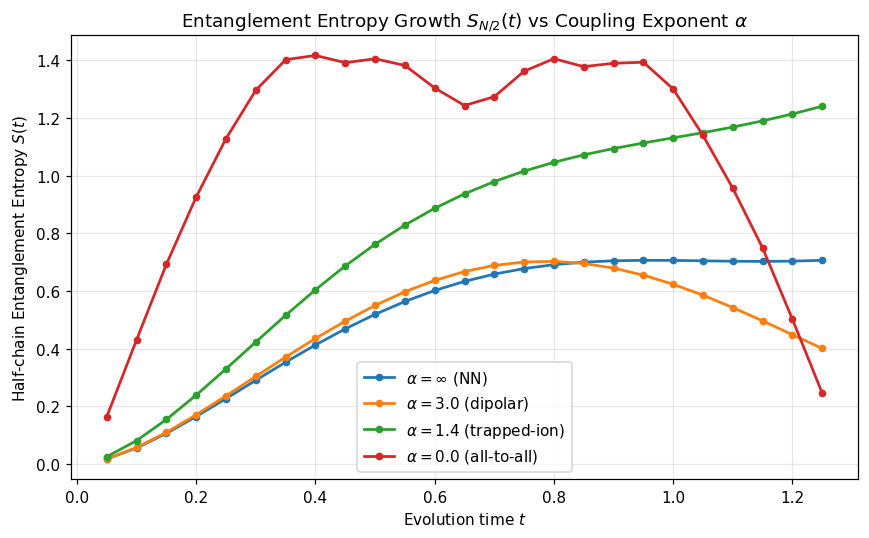

In [18]:
# ==============================================================================
# Task 2: Cross-verify all 4 engines (n=8, alpha=1.5)
# ==============================================================================
n_test = 8
alpha_test = 1.5
dt_test = 0.05
steps_test = 4
J_test, B_test = 1.0, 0.5
t_total = steps_test * dt_test

print("----- Task 2: Verifying Simulator Agreement (n=8, alpha=1.5) -----")

# 1. Statevector simulator
psi_sv = lr_trotter_own_sv(n_test, steps_test, dt_test, alpha_test, J=J_test, B=B_test)
vec_sv = to_flat(psi_sv)

# 2. MPS simulator
mps_test = lr_trotter_own_mps(n_test, steps_test, dt_test, alpha_test, J=J_test, B=B_test, chi_max=64)
vec_mps = to_flat(mps_to_dense(mps_test))

# 3. Qiskit circuit (Statevector)
qc = lr_circuit(n_test, steps_test, dt_test, alpha_test, J=J_test, B=B_test)
vec_qiskit = Statevector.from_instruction(qc).data

# 4. Sparse Krylov evolution (Continuous benchmark)
H_sp = H_longrange_sparse(n_test, alpha_test, J=J_test, B=B_test)
psi_init_flat = to_flat(init_state(n_test))
vec_krylov = evolve_krylov(H_sp, psi_init_flat, t_total)

print("Overlap |<SV | MPS>|     :", abs(np.vdot(vec_sv, vec_mps)))
print("Overlap |<SV | Qiskit>|  :", abs(np.vdot(vec_sv, vec_qiskit)))
print("Overlap |<SV | Krylov>|  :", abs(np.vdot(vec_sv, vec_krylov)), "(differs only by Trotter error)")


# ==============================================================================
# Task 5: Verify GHZ MPS representation (chi = 2)
# ==============================================================================
print("\n----- Task 5: GHZ MPS Verification -----")
n_ghz = 6
mps_g = ghz_mps(n_ghz)
vec_ghz = flat_be(mps_to_dense(mps_g))

# True GHZ state in big-endian: (|00...0> + |11...1>) / sqrt(2)
vec_ghz_exact = np.zeros(2**n_ghz, dtype=complex)
vec_ghz_exact[0] = 1.0 / np.sqrt(2.0)
vec_ghz_exact[-1] = 1.0 / np.sqrt(2.0)

print(f"GHZ MPS max bond dimension: {max_bond(mps_g)}")
print(f"GHZ MPS overlap with exact : {abs(np.vdot(vec_ghz_exact, vec_ghz)):.6f}")
print(f"Half-chain entropy         : {entropy_profile(mps_g)[n_ghz // 2 - 1]:.6f} (ln(2) = {np.log(2):.6f})")


# ==============================================================================
# Tasks 3 & 4: Range dependence (alpha) and entanglement growth S(t)
# ==============================================================================
print("\n----- Tasks 4 & 6: Dynamics and Entanglement Growth -----")
n_dyn = 8
steps_dyn = 25
dt_dyn = 0.05
times = np.arange(1, steps_dyn + 1) * dt_dyn

alphas = [np.inf, 3.0, 1.4, 0.0]
labels = [r"$\alpha=\infty$ (NN)", r"$\alpha=3.0$ (dipolar)", r"$\alpha=1.4$ (trapped-ion)", r"$\alpha=0.0$ (all-to-all)"]

plt.figure(figsize=(8, 5))
for alpha_val, label in zip(alphas, labels):
    _, s_hist = lr_trotter_own_mps(
        n_dyn, steps=steps_dyn, dt=dt_dyn, alpha=alpha_val,
        J=1.0, B=0.5, chi_max=64, track_entropy=True
    )
    plt.plot(times, s_hist, "o-", label=label, lw=1.8, ms=4)

plt.xlabel(r"Evolution time $t$")
plt.ylabel(r"Half-chain Entanglement Entropy $S(t)$")
plt.title(r"Entanglement Entropy Growth $S_{N/2}(t)$ vs Coupling Exponent $\alpha$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Questions for Part 5: The Limits of Classical Simulation

Summarize your findings by testing how far each classical simulation approach can go before breaking.

1. Did using sparse matrices change the scaling problem with system size $n$?
2. As you decrease $\alpha$ from $\infty$ (nearest-neighbour) to 0 (all-to-all interactions), what grows faster: the physical entanglement entropy, the required bond dimension $\chi$, or the gate routing cost? Which resource binds first? *(Hint: consider how many SWAP operations are needed to route non-adjacent gates in 1D).* 
3. A 1000-qubit GHZ state is a highly non-classical superposition, yet an MPS can represent it with a modest bond dimension of $\chi = 2$. What exactly makes a quantum state hard to simulate classically?
4. Based on your numerical observations and research, what is the **entanglement barrier** in tensor network dynamics? How does the entanglement entropy $S(t)$ grow over time during non-equilibrium dynamics? How does the required bond dimension $\chi(t)$ scale with entropy?
5. Can physical quantum computers simulate long-time dynamics better than classical simulators? Why and how does the scaling of a physical quantum processor differ from a classical tensor network simulator? Conversely, what fundamental physical constraints limit physical quantum hardware today?

> Your answer:


---

## References

[1] B. P. Lanyon et al., Universal Digital Quantum Simulation with Trapped Ions, *Science* **334**, 57 (2011).  
[2] U. Schollwöck, The density-matrix renormalization group in the age of matrix product states, *Ann. Phys.* **326**, 96 (2011), arXiv:1008.3477.  
[3] R. Orús, A practical introduction to tensor networks, *Ann. Phys.* **349**, 117 (2014), arXiv:1306.2164.  
[4] M. C. Bañuls, Tensor Networks for Quantum Many-Body Systems, *Annu. Rev. Condens. Matter Phys.* **14**, 173–191 (2023), arXiv:2210.12658.  
[5] M. C. Bañuls et al., Simulating related areas of physics: The tensor networks roadmap, *J. Phys. Mater.* **4**, 024001 (2021), arXiv:2006.14522.  
[6] Qiskit Aer documentation: `matrix_product_state` simulation method.  
[7] TeNPy (Tensor Network Python) documentation: https://tenpy.readthedocs.io/


# 6. Bonus problems (optional, research level)

## 6.1 Realistic Hardware Noise with Qiskit Aer & Fake Backends

Our classical simulators in Parts 1–5 are mathematically exact up to numerical precision ($10^{-14}$) or controlled MPS truncation. Physical quantum processors, however, operate in the presence of physical noise: gate infidelities, qubit decoherence ($T_1$ and $T_2$ relaxation), and measurement readout errors.

On physical quantum devices:
- Two-qubit gates have typical error rates of $10^{-3}$ to $10^{-2}$.
- Operations are restricted to a native hardware basis (e.g. $\sqrt{X}$, $X$, $R_Z$, and $CX$ or $CZ$).
- Qubits have restricted physical connectivity (e.g. heavy-hex lattice), requiring gate routing with SWAPs.

To model real device physics locally on your laptop, Qiskit provides two complementary tools:
1. **Custom Noise Models (`qiskit_aer.noise`)**:
   Add parameterized depolarizing errors or relaxation channels to specific gates.
2. **Fake Hardware Backends (`qiskit.providers.fake_provider`)**:
   Use `GenericBackendV2(num_qubits=...)` to emulate a device with realistic coupling maps, basis gate compilation, $T_1/T_2$ decoherence, and readout errors via `AerSimulator.from_backend(backend)`.

### Tasks
1. Take your Trotter circuit from Part 3 (or the two-qubit instance from Lanyon et al. Figure 1A).
2. Simulate the circuit under depolarizing noise using `NoiseModel` with two-qubit error rates $p \in [0.0, 0.02, 0.08]$.
3. Alternatively, transpile and run your circuit on a fake hardware backend using `GenericBackendV2` and `AerSimulator.from_backend`.
4. Plot the survival probability $P_{\uparrow\uparrow}(t)$ and observe how noise damps the coherent quantum oscillations towards the maximally mixed state ($P_{\uparrow\uparrow} \to 0.5$).

> Hints:
> - Construct a depolarizing noise model in Aer:
>   ```python
>   from qiskit_aer import AerSimulator
>   from qiskit_aer.noise import NoiseModel, depolarizing_error
>   nm = NoiseModel()
>   nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["rxx", "cx"])
>   nm.add_all_qubit_quantum_error(depolarizing_error(p2 / 10, 1), ["rz", "sx"])
>   noisy_sim = AerSimulator(noise_model=nm, basis_gates=["rxx", "rz"])
>   ```
> - Emulate a realistic physical processor:
>   ```python
>   from qiskit.providers.fake_provider import GenericBackendV2
>   backend = GenericBackendV2(num_qubits=5, seed=42)
>   sim = AerSimulator.from_backend(backend)
>   tqc = transpile(qc, backend)
>   counts = sim.run(tqc, shots=4000).result().get_counts()
>   ```


In [15]:
# Your code goes here:
# 1. Set up a noisy simulator with depolarizing noise (or a fake backend)
# 2. Run the Trotter dynamics for increasing time steps
# 3. Plot P_uu(t) across noise levels and compare against the ideal simulation
#
#


### Questions for 6.1

1. In Part 3, we observed that algorithmic Trotterization error decreases as step size $\Delta t \to 0$ (increasing step count $r$). On noisy hardware, what happens as $r$ increases? Explain the fundamental tension between Trotter error and hardware gate noise.
2. In Figure 1A and Figure 4B of Lanyon et al. (2011), the experimental data points decay towards $0.5$ at long times. What error rate $p$ in your simulation best matches their experimental damping?
3. Noise is destructive for quantum hardware, but why can decoherence make classical tensor network simulations *cheaper* (e.g. by destroying long-range entanglement and contracting the Schmidt spectrum)?

> Your answer:


## 6.2 Space-Time Light Cones and Lieb-Robinson Bounds

In special relativity, no physical signal can travel faster than the speed of light $c$, defining a sharp causal light cone. In non-relativistic quantum spin chains with local interactions, an analogous emergent speed limit exists: the Lieb-Robinson bound.

The Lieb-Robinson theorem states that for short-range Hamiltonians, local perturbations cannot propagate faster than a finite maximum group velocity $v_{LR}$ (the Lieb-Robinson velocity):

$$\|[A_i(t), B_j(0)]\| \le C e^{-\mu (d - v_{LR} t)}$$

Outside the causal cone ($|i - j| > v_{LR} t$), quantum correlations remain exponentially suppressed.

To visualize this propagation directly:
1. Prepare an $n$-spin chain initialized in $|00\cdots0\rangle$ ($|{\uparrow\uparrow\cdots\uparrow}\rangle$).
2. At $t = 0$, perturb the system by flipping only the center spin ($i = n//2$) to $|1\rangle$ ($|{\downarrow}\rangle$) using an $X$ gate.
3. Evolve the chain under $H$ over time steps $t \in [0, T]$.
4. At each time step $t$, record the local magnetization $\langle \sigma_z^i \rangle(t) \in [-1, 1]$ at every site $i \in \{0, 1, \dots, n-1\}$.

This produces a 2D matrix of shape `(n_time_steps, n_sites)`:
- Horizontal axis (Space): Site index $i$ along the chain.
- Vertical axis (Time): Evolution time $t$, flowing upwards from $t=0$.
- Color: Value of $\langle \sigma_z^i \rangle(t)$ (e.g. blue for $+1$ / undisturbed spin-up, red for $-1$ / spin-down).

As time increases, the disturbance at the center spreads outwards to neighboring sites $i \pm 1, i \pm 2, \dots$ at speed $v_{LR}$, drawing a distinctive triangular V-shaped cone (the light cone) on the space-time plot!

### Tasks
1. Prepare an $n$-qubit chain in $|00\cdots0\rangle$ (e.g. $n = 11$ or $15$) and flip the center spin at $t = 0$.
2. Evolve under the transverse-field Ising model up to time $T = 3.0$.
3. Compute the local magnetization $\langle \sigma_z^i \rangle(t)$ across all sites $i$ at each time step.
4. Plot the resulting space-time heatmap for nearest-neighbor interactions ($\alpha = \infty$) versus long-range interactions ($\alpha = 2.0$).

> Hints:
> - Measure local magnetization using `expect_1site_mps(mps, Z, i)` (or statevector expectations).
> - Plot the 2D profile using:
>   ```python
>   plt.imshow(profile, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1,
>              extent=[0, n - 1, 0, T])
>   plt.xlabel("site i"); plt.ylabel("time t")
>   plt.colorbar(label=r"$\langle\sigma_z^i\rangle$")
>   ```


In [16]:
# Your code goes here:
# 1. Simulate dynamics after flipping the center spin
# 2. Collect the space-time profile of <sigma_z^i>(t)
# 3. Plot the space-time heatmap for alpha = infinity vs alpha = 2.0
#
#


### Questions for 6.2

1. Measure the slope of the propagation front for nearest-neighbor couplings ($\alpha = \infty$). What is the measured velocity $v_{LR}$?
2. Compare the nearest-neighbor heatmap with the long-range case ($\alpha = 2.0$). Why are they different? What is going on here?
3. Connect this propagation velocity to the entanglement barrier from Part 5: why does entanglement across a cut at position $x$ only begin growing after the light cone reaches it?

> Your answer:
